# Executive Summary | Resumo Executivo

## 1. Business Context | Contexto de Negócio

### 🇧🇷 Português

O objetivo deste projeto foi analisar a evolução de receita do marketplace da :contentReference[oaicite:0]{index=2} e identificar padrões estratégicos de negócio.

As principais perguntas de negócio foram:

- Como a receita evoluiu ao longo do tempo?
- Existe concentração de receita entre sellers?
- Quais riscos comerciais podem impactar o crescimento futuro?
- Quais oportunidades estratégicas podem ser exploradas?

---

### 🇺🇸 English

The objective of this project was to analyze marketplace revenue behavior and identify strategic business patterns.

Main business questions:

- How did marketplace revenue evolve over time?
- Is revenue concentrated among sellers?
- What commercial risks may impact future growth?
- What strategic opportunities can be explored?

## 2. Key Findings | Principais Descobertas

### Finding 1 — Revenue Concentration

86.79% of total marketplace revenue comes from Top Performers.

This reveals strong commercial concentration and dependency on a small group of sellers.

---

### Finding 2 — Seller Distribution

Although sellers were evenly distributed into four segments:

- Long Tail
- Emerging
- Strong
- Top Performers

Revenue distribution was highly unequal.

---

### Finding 3 — Commercial Exposure

The marketplace may face significant revenue risk if strategic sellers leave the platform.

Marketplace base created successfully.
Rows: 112650
Columns: 16


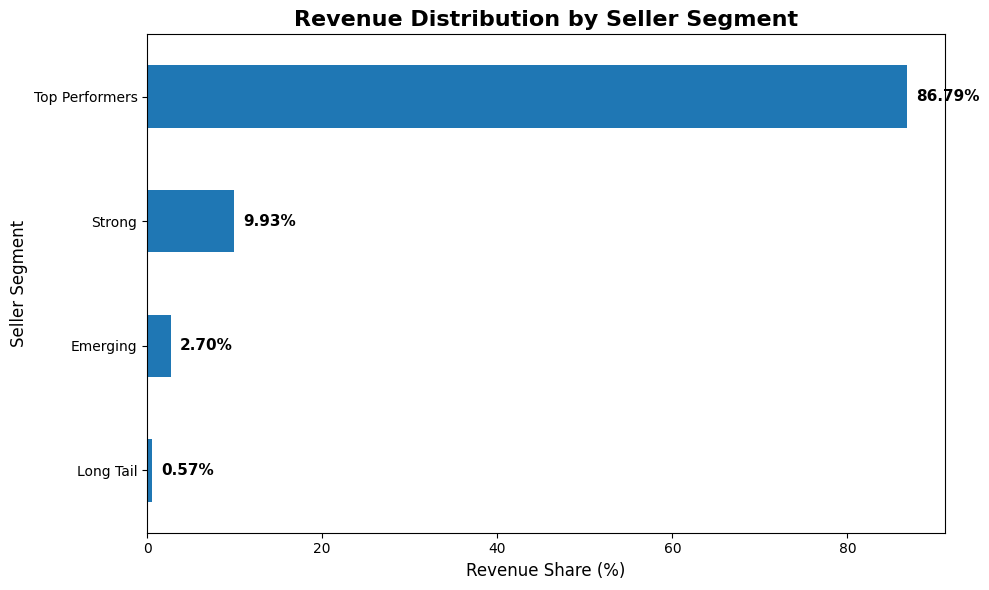

In [5]:
# Imports
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

# Project path setup
project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# Internal imports
from src.data_ingestion import build_marketplace_base


# Load data
df = build_marketplace_base()


# Seller revenue aggregation
seller_revenue_df = (
    df.groupby("seller_id")["payment_value"]
    .sum()
    .reset_index()
)

seller_revenue_df.columns = [
    "seller_id",
    "revenue"
]


# Seller segmentation
seller_revenue_df["segment"] = pd.qcut(
    seller_revenue_df["revenue"],
    q=4,
    labels=[
        "Long Tail",
        "Emerging",
        "Strong",
        "Top Performers"
    ]
)


# Revenue by segment (%)
segment_revenue_pct = (
    seller_revenue_df
    .groupby("segment")["revenue"]
    .sum()
)

segment_revenue_pct = (
    segment_revenue_pct
    / segment_revenue_pct.sum()
) * 100

segment_revenue_pct = (
    segment_revenue_pct
    .round(2)
)



# Revenue concentration by seller segment
plt.figure(figsize=(10, 6))

segment_revenue_pct.sort_values().plot(
    kind="barh"
)

plt.title(
    "Revenue Distribution by Seller Segment",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Revenue Share (%)",
    fontsize=12
)

plt.ylabel(
    "Seller Segment",
    fontsize=12
)

# Add percentage labels
for index, value in enumerate(
    segment_revenue_pct.sort_values().values
):
    plt.text(
        value + 1,
        index,
        f"{value:.2f}%",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

# Business Risks | Riscos de Negócio

## 🇧🇷 Português

Com base na análise de concentração de sellers, foram identificados riscos estratégicos para o marketplace:

### 1. Seller Churn Risk
A saída de sellers estratégicos pode impactar significativamente a receita.

### 2. Revenue Dependency
A forte concentração em poucos sellers cria dependência comercial.

### 3. Growth Limitation
A baixa participação dos segmentos Emerging e Long Tail pode limitar expansão futura.

---

## 🇺🇸 English

Based on seller concentration analysis, strategic marketplace risks were identified:

### 1. Seller Churn Risk
The loss of strategic sellers may significantly impact revenue.

### 2. Revenue Dependency
High concentration among a few sellers creates commercial dependency.

### 3. Growth Limitation
Low participation from Emerging and Long Tail sellers may limit future growth.

## 3. Business Risks | Riscos de Negócio

### 🇧🇷 Português

Com base na análise de concentração de sellers, foram identificados três riscos estratégicos para o marketplace:

### 1. Seller Churn Risk

A saída de sellers estratégicos pode gerar impacto direto e imediato na receita.

Como a maior parte da receita está concentrada em poucos sellers, a perda desses parceiros pode comprometer a estabilidade financeira do marketplace.

---

### 2. Revenue Dependency

A forte concentração de receita cria dependência comercial.

Esse cenário reduz a previsibilidade de crescimento e aumenta a vulnerabilidade operacional.

---

### 3. Growth Limitation

A baixa participação dos segmentos Emerging e Long Tail pode limitar expansão futura.

Sem desenvolvimento desses sellers, o marketplace pode enfrentar dificuldades para diversificar receita.

---

## 🇺🇸 English

Based on seller concentration analysis, three strategic marketplace risks were identified:

### 1. Seller Churn Risk

The loss of strategic sellers may create immediate revenue impact.

Since most revenue comes from a small seller group, losing these partners could compromise marketplace financial stability.

---

### 2. Revenue Dependency

High revenue concentration creates commercial dependency.

This reduces growth predictability and increases operational vulnerability.

---

### 3. Growth Limitation

Low participation from Emerging and Long Tail sellers may limit future expansion.

Without developing these sellers, the marketplace may struggle to diversify revenue sources.

## 4. Growth Opportunities | Oportunidades de Crescimento

### 🇧🇷 Português

Com base nos padrões identificados, três oportunidades estratégicas foram mapeadas:

### 1. Seller Retention Program

Criar programas de retenção para sellers estratégicos.

Objetivo:

Reduzir risco de churn e proteger a principal fonte de receita.

---

### 2. Emerging Seller Development

Desenvolver sellers do segmento Emerging.

Objetivo:

Aumentar performance comercial e criar novos sellers estratégicos no médio prazo.

---

### 3. Revenue Diversification

Estimular crescimento dos segmentos menores.

Objetivo:

Reduzir dependência dos Top Performers e aumentar sustentabilidade do marketplace.

---

## 🇺🇸 English

Based on the identified patterns, three strategic growth opportunities were mapped:

### 1. Seller Retention Program

Create retention initiatives for strategic sellers.

Goal:

Reduce churn risk and protect the main revenue source.

---

### 2. Emerging Seller Development

Develop sellers in the Emerging segment.

Goal:

Increase commercial performance and create future strategic sellers.

---

### 3. Revenue Diversification

Stimulate growth among smaller seller segments.

Goal:

Reduce dependency on Top Performers and improve marketplace sustainability.

## 5. Executive Action Plan | Plano Executivo de Ação

### 🇧🇷 Português

Com base nos insights encontrados, o seguinte plano de ação de 90 dias foi proposto:

| Timeline | Strategic Action | Expected Business Impact |
|----------|------------------|--------------------------|
| 0–30 Days | Identificar sellers estratégicos com maior impacto de receita | Redução de risco comercial |
| 30–60 Days | Implementar programas de retenção e relacionamento | Proteção da receita atual |
| 60–90 Days | Desenvolver sellers Emerging e monitorar diversificação | Crescimento sustentável |

---

## 🇺🇸 English

Based on the identified insights, the following 90-day action plan was proposed:

| Timeline | Strategic Action | Expected Business Impact |
|----------|------------------|--------------------------|
| 0–30 Days | Identify strategic sellers with highest revenue impact | Commercial risk reduction |
| 30–60 Days | Launch retention and relationship programs | Current revenue protection |
| 60–90 Days | Develop Emerging sellers and monitor diversification | Sustainable growth |

## 6. Executive Conclusion | Conclusão Executiva

### 🇧🇷 Português

A análise revelou que o marketplace apresenta alta concentração de receita entre sellers estratégicos.

Embora esse modelo sustente forte performance no curto prazo, ele também aumenta a exposição a riscos comerciais.

O crescimento sustentável dependerá da retenção de sellers premium e do desenvolvimento de segmentos menores.

---

### 🇺🇸 English

The analysis revealed that the marketplace shows high revenue concentration among strategic sellers.

Although this model supports strong short-term performance, it also increases commercial exposure.

Sustainable growth will depend on premium seller retention and smaller segment development.